# **Challenge 2 Telecom X**

Foco do Projeto:

O principal objetivo deste desafio é desenvolver as habilidades em ETL (Extract, Transform, Load) com Python.


Etapas:
## - 1º Extração
## - 2º Tranformação
## - 3º Carga
## - 4º Análise Exploratória
## - 5º Relatório Final

# **1º Extração**

In [ ]:
import pandas as pd
import requests
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# url do dataset bruto

url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json'

# 2º 🔧 **Transformação**

In [ ]:
# Extraindo e normalizando a estrutura JSON para o df
df = pd.json_normalize(pd.read_json(url).to_dict(orient='records'))

# Renomeando as colunas para português (Normalização de nomes)
traducao = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasao_Churn',
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Idoso',
    'customer.Partner': 'Parceiro',
    'customer.Dependents': 'Dependentes',
    'customer.tenure': 'Meses_Contrato',
    'phone.PhoneService': 'Servico_Telefone',
    'phone.MultipleLines': 'Multiplas_Linhas',
    'internet.InternetService': 'Servico_Internet',
    'internet.OnlineSecurity': 'Seguranca_Online',
    'internet.OnlineBackup': 'Backup_Online',
    'internet.DeviceProtection': 'Protecao_Dispositivo',
    'internet.TechSupport': 'Suporte_Tecnico',
    'internet.StreamingTV': 'Streaming_TV',
    'internet.StreamingMovies': 'Streaming_Filmes',
    'account.Contract': 'Tipo_Contrato',
    'account.PaperlessBilling': 'Fatura_Digital',
    'account.PaymentMethod': 'Metodo_Pagamento',
    'account.Charges.Monthly': 'Valor_Mensal',
    'account.Charges.Total': 'Valor_Total'
}

# Aplicando a renomeação direto no objeto
df.rename(columns=traducao, inplace=True)

df

,ID_Cliente,Evasao_Churn,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Servico_Internet,...,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Valor_Mensal,Valor_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [ ]:
# 1. Definindo as colunas que possuem valores 'Yes'/'No'
colunas_para_converter = [
    'Evasao_Churn', 'Parceiro', 'Dependentes', 'Servico_Telefone',
    'Multiplas_Linhas', 'Seguranca_Online', 'Backup_Online',
    'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_TV',
    'Streaming_Filmes', 'Fatura_Digital'
]

# 2. Criando o mapeamento
mapeamento = {'Yes': 1, 'No': 0}

# 3. Aplicando a conversão (usando fillna(0) para tratar casos como 'No internet service')
for col in colunas_para_converter:
    df[col] = df[col].map(mapeamento).fillna(0).astype(int)

# 4. Tratando a coluna Valor_Total que você já sabe que tem espaços vazios
df['Valor_Total'] = df['Valor_Total'].replace(' ', '0').astype(float)

df.head()

,ID_Cliente,Evasao_Churn,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Servico_Internet,...,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Valor_Mensal,Valor_Total
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.6,593.30
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40


# **3º 📊 Carga**

In [ ]:
# Guardando o DataFrame em outra variável e salvando o csv

dados = df.copy()

dados.to_csv('dados_telecom_x_limpo.csv', index=False)

In [ ]:
dados_limpos = pd.read_csv('/content/dados_telecom_x_limpo.csv')

dados_limpos

,ID_Cliente,Evasao_Churn,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Servico_Internet,...,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Valor_Mensal,Valor_Total
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.60,593.30
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,Female,0,0,0,13,1,0,DSL,...,0,0,1,0,0,One year,0,Mailed check,55.15,742.90
7263,9992-RRAMN,1,Male,0,1,0,22,1,1,Fiber optic,...,0,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70
7264,9992-UJOEL,0,Male,0,0,0,2,1,0,DSL,...,1,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75
7265,9993-LHIEB,0,Male,0,1,1,67,1,0,DSL,...,0,1,1,0,1,Two year,0,Mailed check,67.85,4627.65


# **4º 📊 Análise Exploratória**

In [ ]:
# Calculando a Taxa Geral de Churn usando os novos valores numéricos (1 e 0)

# O valor 1 representa o 'Yes' (Evasão)
taxa_evasao = dados_limpos['Evasao_Churn'].value_counts(normalize=True) * 100

# Agora buscamos pelo índice 1 em vez de 'Yes'
print(f"Taxa de Churn Atual: {taxa_evasao[1]:.2f}%")
print('-' * 30)
print("Legenda: 1 = Sim (Saiu), 0 = Não (Ficou)")
print(dados_limpos['Evasao_Churn'].value_counts())

Taxa de Churn Atual: 25.72%
------------------------------
Legenda: 1 = Sim (Saiu), 0 = Não (Ficou)
Evasao_Churn
0    5398
1    1869
Name: count, dtype: int64


In [ ]:
# 1. Criamos apenas a coluna de perfil para exibição
dados_limpos['Perfil_Idade'] = dados_limpos['Idoso'].map({0: 'Jovem', 1: 'Idoso'})

# 2. Geramos a Tabela Dinâmica direto com 'Evasao_Churn'
perfil_tabela = dados_limpos.pivot_table(
    index='Tipo_Contrato',
    columns='Perfil_Idade',
    values='Evasao_Churn', # Usando a coluna que já é 0 ou 1
    aggfunc='mean'
)

perfil_tabela.style.format("{:.2%}")\
            .background_gradient(cmap='Greens')

Perfil_Idade,Idoso,Jovem
Tipo_Contrato,,
Month-to-month,52.88%,38.28%
One year,14.80%,10.36%
Two year,3.95%,2.64%


In [ ]:
# 4. Criando o Styler ajustado com cabeçalhos e índices em branco
s_final = tabela_final.style.format("{:.2f}%") \
    .background_gradient(cmap='Reds', subset=['Jovem', 'Idoso', 'Impacto Adicional']) \
    .set_caption("Análise de Risco: Churn por Perfil Etário e Contrato") \
    .set_properties(**{'text-align': 'center', 'padding': '10px'}) \
    .set_table_styles([
        # Estilo para os Cabeçalhos (Colunas)
        {'selector': 'th', 'props': [
            ('background-color', 'white'),
            ('color', '#333'),
            ('font-weight', 'bold'),
            ('border', '1px solid #ddd')
        ]},
        # Estilo para os Índices (Linhas)
        {'selector': 'th.row_heading', 'props': [
            ('background-color', 'white'),
            ('color', '#333'),
            ('border', '1px solid #ddd')
        ]},

        {'selector': 'table', 'props': [('background-color', 'white')]}
    ])

s_final

Perfil_Idade,Jovem,Idoso,Impacto Adicional
Tipo_Contrato,,,
Month-to-month,38.28%,52.88%,14.59%
One year,10.36%,14.80%,4.44%
Two year,2.64%,3.95%,1.31%


## Insights:

- Taxa de 25,72% de Churn é um número alto para telecomunicações, isso significa que mais de 1/4 da base está indo embora. Temos um problema real para resolver.

- O Vilão Principal: O contrato Month-to-month (mês a mês). Mesmo para não-idosos (38.28%), a evasão é altíssima comparada aos contratos de dois anos (2.64%).

- Fator de Risco (Idosos): Em todos os tipos de contrato, a taxa de evasão dos idosos é consideravelmente maior.

- A Solução Térmica: O contrato de dois anos "congela" o Churn. não idoso 2,6% e idoso 4%. A estratégia da empresa deveria ser converter clientes mensais em anuais/bienais o mais rápido possível.

In [ ]:
# Analisando a média de Valor Mensal para quem sai e quem fica
analise_financeira = dados_limpos.groupby('Evasao_Churn')['Valor_Mensal'].agg(['mean', 'median', 'std'])

# Formatando para exibir como moeda
analise_financeira.style.format("R$ {:.2f}").background_gradient(cmap='YlOrRd')


,mean,median,std
Evasao_Churn,,,
0,R$ 61.35,R$ 64.50,R$ 31.11
1,R$ 74.44,R$ 79.65,R$ 24.67


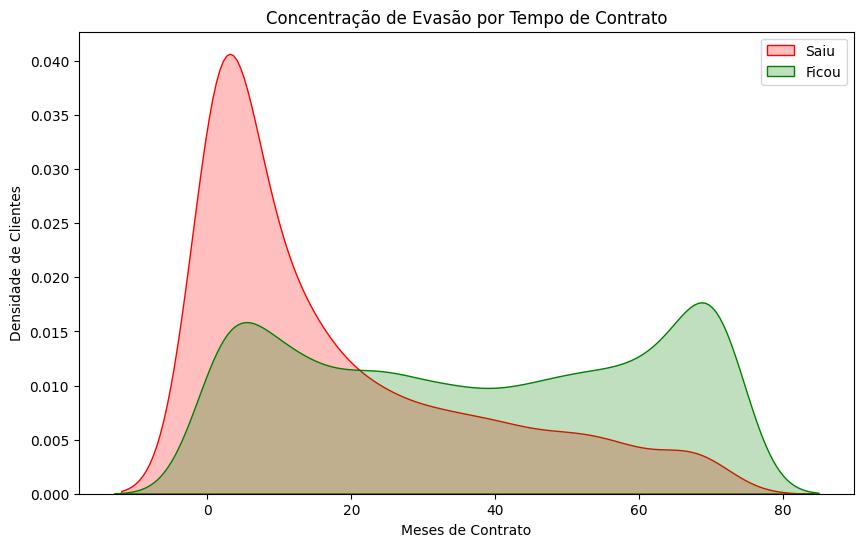

In [ ]:
plt.figure(figsize=(10, 6))
# Criando um gráfico de densidade para ver onde o Churn (1) se concentra
sns.kdeplot(data=df[df['Evasao_Churn'] == 1], x='Meses_Contrato', label='Saiu', fill=True, color='red')
sns.kdeplot(data=df[df['Evasao_Churn'] == 0], x='Meses_Contrato', label='Ficou', fill=True, color='green')

plt.title('Concentração de Evasão por Tempo de Contrato')
plt.xlabel('Meses de Contrato')
plt.ylabel('Densidade de Clientes')
plt.legend()
plt.show()

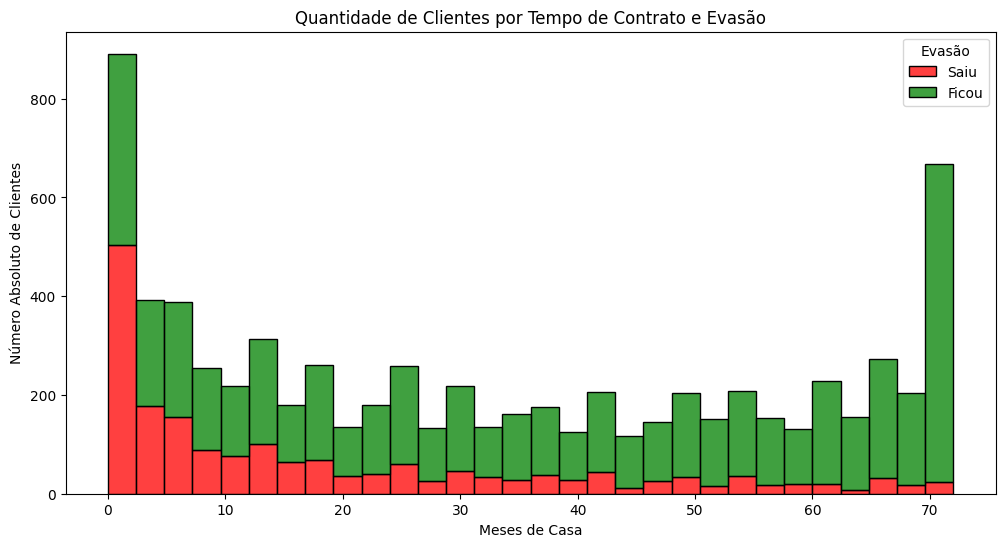

In [ ]:
plt.figure(figsize=(12, 6))

# Usando histplot para mostrar valores absolutos (contagem)
sns.histplot(data=df, x='Meses_Contrato', hue='Evasao_Churn',
             multiple='stack', # Empilha as barras para ver o total
             palette=['green', 'red'],
             bins=30) # Divide o tempo em 30 blocos

plt.title('Quantidade de Clientes por Tempo de Contrato e Evasão')
plt.xlabel('Meses de Casa')
plt.ylabel('Número Absoluto de Clientes')
plt.legend(title='Evasão', labels=['Saiu', 'Ficou'])
plt.show()

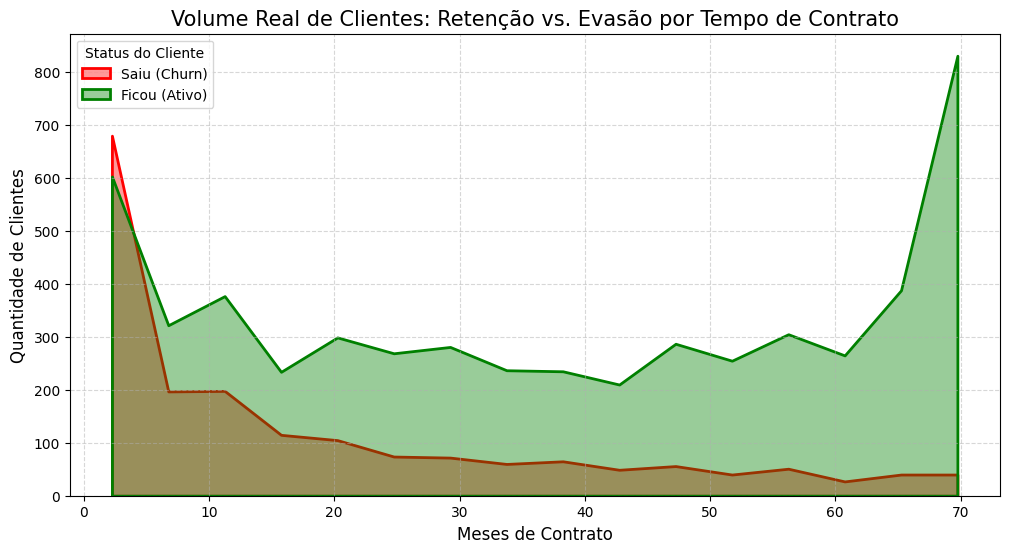

In [ ]:
# Configurando o tamanho da figura
plt.figure(figsize=(12, 6))

# Usamos histplot com element="poly" para simular o gráfico de área com contagem real
sns.histplot(
    data=df,
    x='Meses_Contrato',
    hue='Evasao_Churn',
    element="poly",      # Cria a forma de polígono (área suave)
    fill=True,           # Preenche a área
    common_norm=False,   # Mantém as contagens independentes
    palette={0: 'green', 1: 'red'},
    alpha=0.4,
    linewidth=2
)

# Ajustando legendas claras e diretas
plt.title('Volume Real de Clientes: Retenção vs. Evasão por Tempo de Contrato', fontsize=15)
plt.xlabel('Meses de Contrato', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12) # Agora é contagem real!
plt.grid(True, linestyle='--', alpha=0.5)

# Forçando a legenda a ser amigável para qualquer pessoa entender
plt.legend(title='Status do Cliente', labels=['Saiu (Churn)', 'Ficou (Ativo)'])

plt.show()

# **5. 📄Relatorio Final**

Análise Concluída: Os insights estratégicos sobre a retenção de clientes e as recomendações para redução de Churn detalhadas estão disponíveis no relatório final.

[Acessar Relatório Final (PDF)](https://github.com/vanrpontes/challenge2-telecom_x/blob/main/relatorio/challenge2_telecom_x.pdf)